### Decision Tree Classifier (Using Iris Dataset)

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Accuracy
accuracy = clf.score(X_test, y_test)
print(f"Decision Tree Accuracy: {accuracy:.2f}\n")

# Display tree structure as text (simplified view)
r = export_text(clf, feature_names=iris.feature_names)
print("Simplified Tree Structure:\n", r)

Decision Tree Accuracy: 0.98

Simplified Tree Structure:
 |--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal length (cm) <= 5.15
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  5.15
|   |   |   |--- class: 2



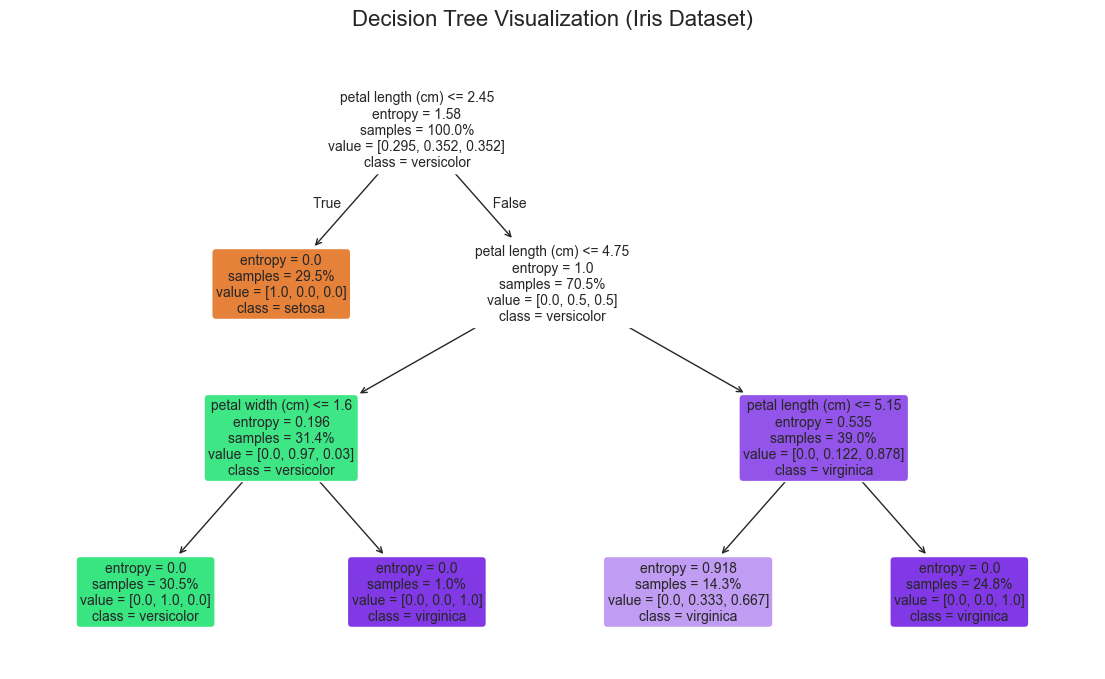

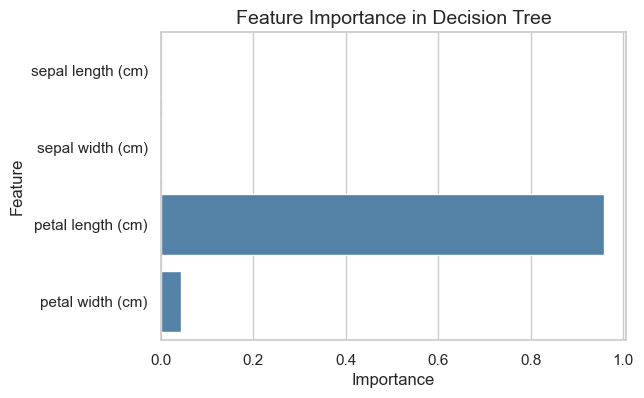

In [14]:
# --- Visualization ---
plt.figure(figsize=(14, 8))
tree.plot_tree(
    clf,
    filled=True,
    rounded=True,
    fontsize=10,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    proportion=True,
)
plt.title("Decision Tree Visualization (Iris Dataset)", fontsize=16, pad=20)
plt.show()

# --- Feature Importance Bar Plot ---
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=clf.feature_importances_, y=iris.feature_names, color="steelblue")
plt.title("Feature Importance in Decision Tree", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Random Forest Classifier (Using Iris Dataset)

In [3]:
# --- Improved Random Forest Visualization ---

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc:.2f}")

Random Forest Accuracy: 1.00


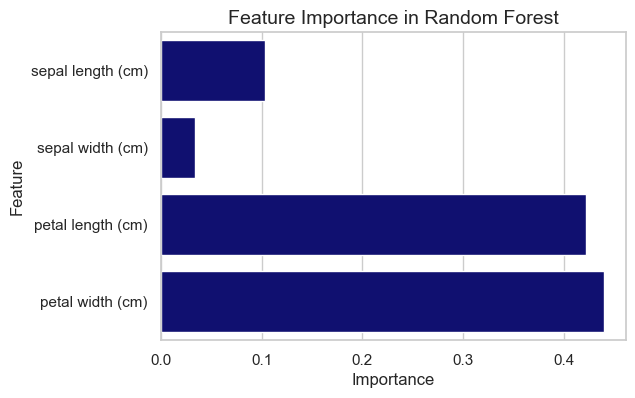

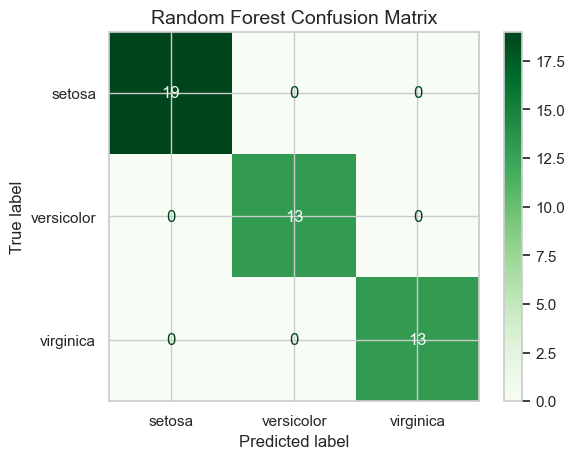

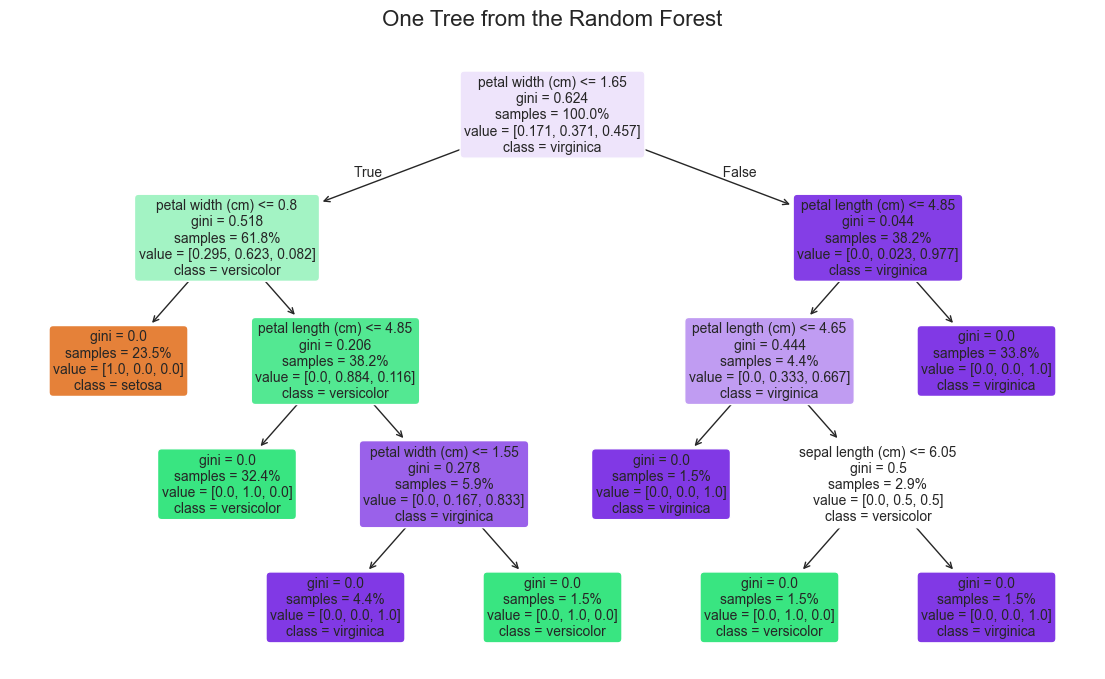

In [16]:
# --- Feature Importance Visualization ---
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=rf.feature_importances_, y=iris.feature_names, color="navy")
plt.title("Feature Importance in Random Forest", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --- Confusion Matrix ---
disp = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=iris.target_names, cmap="Greens")
plt.title("Random Forest Confusion Matrix", fontsize=14)
plt.show()

# --- Visualize One Tree from the Forest ---
from sklearn import tree
plt.figure(figsize=(14, 8))
tree.plot_tree(
    rf.estimators_[0],
    filled=True,
    rounded=True,
    fontsize=10,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    proportion=True,
)
plt.title("One Tree from the Random Forest", fontsize=16, pad=20)
plt.show()
